# Seminární práce z předmětu Počítačové zpracování signálu (KI/PZS)
**Téma:** 1. Výpočet tepové frekvence z EKG signálu

**Autor:** Karel Murgač

## Zadání
Cílem této části je navrhnout algoritmus pro automatickou detekci R-vrcholů v EKG signálu a výpočet tepové frekvence.
Algoritmus bude aplikován na databázi **DriveDB** (monitoring řidičů) a následně validován na databázi **MIT-BIH (NSRDB)**.

**Postup řešení:**
1. Načtení dat pomocí knihovny `wfdb`.
2. Detekce R-vrcholů (dominantních peaků) v signálu.
3. Výpočet tepové frekvence (BPM).
4. Vizualizace výsledků a zhodnocení úspěšnosti.

In [10]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os

# Nastavení grafů pro lepší čitelnost
plt.rcParams['figure.figsize'] = [15, 5]
print("Knihovny úspěšně načteny.")

Knihovny úspěšně načteny.


## 1. Návrh algoritmu pro detekci R-vrcholů

[cite_start]Podle zadání určuje vzdálenost R-vrcholů dobu mezi tepy. Tepová frekvence (Heart Rate - HR) se vypočítá jako počet těchto vrcholů za minutu.

Můj algoritmus využívá funkci `find_peaks` z knihovny `scipy`, která hledá lokální maxima. Abychom detekovali pouze R-vrcholy (a ne šum nebo vlnu T), nastavíme následující parametry:
* **Výška (height):** Ignorujeme vrcholy nižší než určitá hranice (např. 50 % maximální výchylky signálu).
* **Vzdálenost (distance):** Lidské srdce má fyzikální limit, jak rychle může tlouct. Nastavíme minimální rozestup mezi vrcholy (např. odpovídající tepu 200 BPM), aby nedošlo k dvojí detekci jednoho tepu.

Vzorec pro výpočet tepové frekvence z průměrného intervalu mezi vrcholy (RR interval):

$$HR = \frac{60}{\text{průměrný RR interval (s)}}$$

In [11]:
def analyzuj_ekg(signal, fs, nazev_zaznamu="Neznámý", vykreslit=False):
    """
    Robustní verze: Používá percentily pro určení orientace signálu.
    To zabrání chybám, když jeden velký artefakt zmate detekci.
    """
    
    # 1. Centralizace (dostaneme signál na nulu podle mediánu)
    signal_centered = signal - np.median(signal)

    # 2. Rozhodnutí o orientaci (Percentilová metoda)
    # Místo min/max koukáme na 1. a 99. percentil. 
    # To nám řekne, kde je "většina" energie signálu, aniž by nás zmátl jeden náhodný výkyv.
    p1 = np.percentile(signal_centered, 1)   # Hranice spodních 99 % dat
    p99 = np.percentile(signal_centered, 99) # Hranice horních 99 % dat
    
    # Pokud je "dno" hlubší než je "strop" vysoký, otočíme signál.
    if np.abs(p1) > np.abs(p99):
        signal_pro_detekci = -signal_centered
    else:
        signal_pro_detekci = signal_centered

    # 3. Nastavení prahu
    # Znovu použijeme percentil na (už správně otočeném) signálu
    robust_max = np.percentile(signal_pro_detekci, 99.5)
    
    # Práh: 40 % z výšky robustního maxima
    min_height = 0.4 * robust_max
    
    # Vzdálenost: min 0.3 sekundy mezi tepy
    min_distance = int(0.3 * fs) 
    
    # 4. Detekce
    r_peaks, _ = find_peaks(signal_pro_detekci, height=min_height, distance=min_distance)
    
    # 5. Výpočet BPM
    if len(r_peaks) > 1:
        rr_intervals = np.diff(r_peaks) / fs
        avg_rr = np.mean(rr_intervals)
        bpm = 60 / avg_rr
    else:
        bpm = 0

    # 6. Grafika
    if vykreslit:
        limit_vzorku = int(min(len(signal), 10 * fs))
        t = np.arange(limit_vzorku) / fs
        
        plt.figure(figsize=(12, 5))
        
        # Vykreslíme signál, na kterém proběhla detekce (měl by mít špičky NAHORU)
        plt.plot(t, signal_pro_detekci[:limit_vzorku], label='Upravený signál', color='steelblue')
        
        peaks_to_plot = r_peaks[r_peaks < limit_vzorku]
        plt.plot(peaks_to_plot / fs, signal_pro_detekci[peaks_to_plot], "x", color='red', markersize=10, label='Detekované R-vrcholy')
        
        plt.hlines(min_height, 0, t[-1], colors='green', linestyles='dashed', label='Práh')

        plt.title(f"Záznam: {nazev_zaznamu} | BPM: {bpm:.1f}")
        plt.xlabel("Čas [s]")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
    return bpm, r_peaks

## 2. Aplikace na databázi DriveDB

Nyní načteme 17 měření z databáze `drivedb`. Data mám stažená lokálně.
Pro každý soubor načteme signál, zjistíme vzorkovací frekvenci a aplikujeme naši funkci.

*Poznámka: Názvy souborů v databázi jsou obvykle ve formátu `drive01`, `drive02`, atd.*

Zpracovávám tyto záznamy: ['drive01', 'drive02', 'drive03', 'drive04', 'drive05', 'drive06', 'drive07', 'drive08', 'drive09', 'drive10', 'drive11', 'drive12', 'drive13', 'drive14', 'drive15', 'drive16', 'drive17a', 'drive17b']
Zpracování DriveDB...


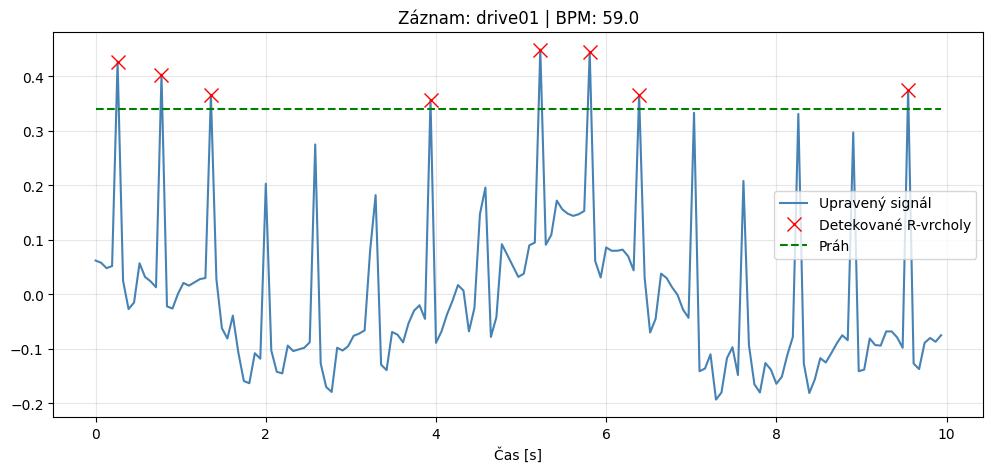

drive01: 59.03 BPM
drive02: 128.43 BPM
drive03: 74.25 BPM
drive04: 77.28 BPM
drive05: 0.00 BPM
drive06: 97.70 BPM
drive07: 83.17 BPM
drive08: 119.86 BPM
drive09: 118.30 BPM
drive10: 61.46 BPM
drive11: 111.10 BPM
drive12: 61.57 BPM
drive13: 92.61 BPM
drive14: 92.61 BPM
drive15: 116.46 BPM
drive16: 24.32 BPM
drive17a: 76.11 BPM
drive17b: 8.95 BPM


In [12]:
cesta_k_drivedb = 'data' 

# 1. Vytvoříme seznam pro drive01 až drive16
zaznamy_drive = [f"drive{i:02d}" for i in range(1, 17)]

# 2. Ručně přidáme drive17a a drive17b, protože drive17 neexistuje
zaznamy_drive.append("drive17a")
zaznamy_drive.append("drive17b")

vysledky_drive = []

print("Zpracovávám tyto záznamy:", zaznamy_drive)
print("Zpracování DriveDB...")

for nazev in zaznamy_drive:
    try:
        # Načtení záznamu (header i signál)
        # pn_dir=None znamená, že nehledáme na internetu, ale lokálně
        record = wfdb.rdrecord(os.path.join(cesta_k_drivedb, nazev))
        
        # Získání EKG signálu (obvykle první kanál, ale ověříme)
        # Signály jsou v record.p_signal
        # Názvy kanálů v record.sig_name
        
        index_ekg = -1
        for i, sig_name in enumerate(record.sig_name):
            # Hledáme kanál, který má v názvu 'ECG' nebo je to typický EKG
            if "ECG" in sig_name.upper() or "EKG" in sig_name.upper():
                index_ekg = i
                break
        
        if index_ekg == -1:
            # Pokud nenajde název, zkusíme vzít první kanál (často bývá EKG u drivedb)
            # Ale v drivedb může být i EMG, zkontroluj názvy kanálů printem: print(record.sig_name)
            index_ekg = 0 
            
        signal = record.p_signal[:, index_ekg]
        fs = record.fs # Vzorkovací frekvence
        
        # Analýza (vykreslíme jen první záznam pro kontrolu)
        ukazat_graf = (nazev == "drive01") 
        bpm, _ = analyzuj_ekg(signal, fs, nazev_zaznamu=nazev, vykreslit=ukazat_graf)
        
        vysledky_drive.append((nazev, bpm))
        print(f"{nazev}: {bpm:.2f} BPM")
        
    except Exception as e:
        print(f"Chyba při zpracování {nazev}: {e}")


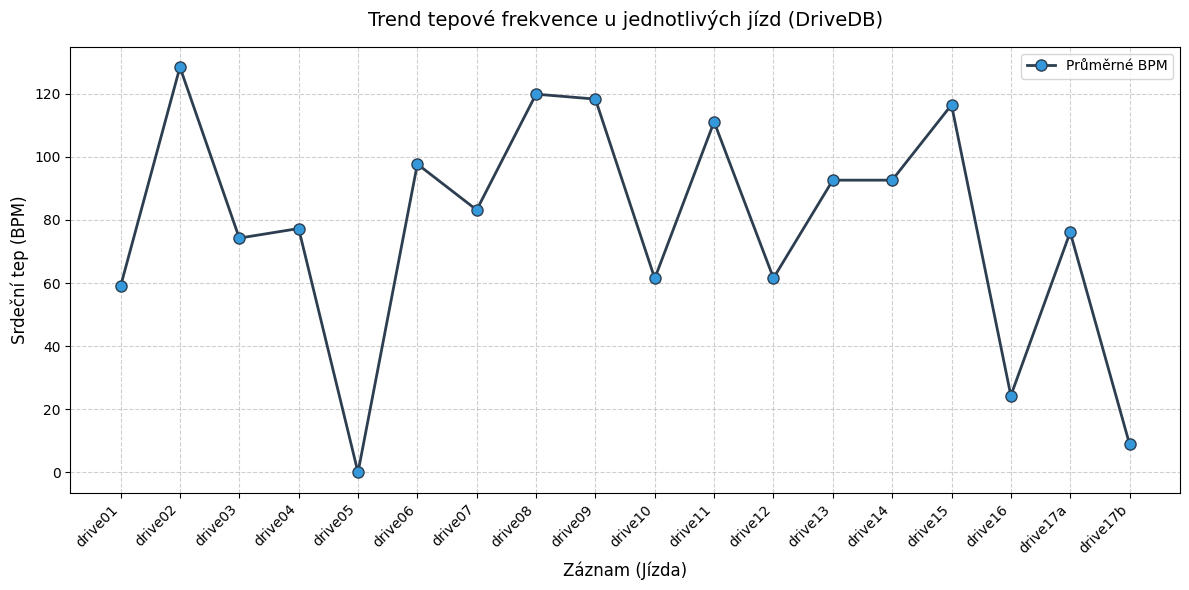

In [13]:
# --- Vykreslení souhrnného grafu BPM (ČÁROVÝ GRAF) ---
nazvy = [x[0] for x in vysledky_drive]
hodnoty = [x[1] for x in vysledky_drive]

plt.figure(figsize=(12, 6))

# Vykreslení čáry se značkami ('-o' vytvoří čáru i body)
plt.plot(nazvy, hodnoty, marker='o', linestyle='-', color='#2c3e50', 
         linewidth=2, markersize=8, markerfacecolor='#3498db', label='Průměrné BPM')

# Přidání vodorovné čáry pro průměr (volitelné, pro kontext)
# bpm_avg = sum(hodnoty) / len(hodnoty)
# plt.axhline(y=bpm_avg, color='red', linestyle='--', alpha=0.5, label=f'Celkový průměr: {bpm_avg:.1f}')

plt.title("Trend tepové frekvence u jednotlivých jízd (DriveDB)", fontsize=14, pad=15)
plt.ylabel("Srdeční tep (BPM)", fontsize=12)
plt.xlabel("Záznam (Jízda)", fontsize=12)

# Oprava překrývání textu na ose X
plt.xticks(rotation=45, ha='right')

# Mřížka pro lepší čitelnost hodnot
plt.grid(True, linestyle='--', alpha=0.6)

# Automatické upravení okrajů
plt.tight_layout()

plt.legend()
plt.show()

## 3. Validace algoritmu na databázi MIT-BIH Arrhythmia

Dle zadání musíme otestovat algoritmus na anotovaných datech z databáze **MIT-BIH Arrhythmia** (celkem 48 záznamů).
Tato databáze obsahuje záznamy EKG s různými typy srdečních arytmií a expertně označenými R-vrcholy.

**Metodika validace:**
1. Načteme signál pro každý ze 48 záznamů z MIT-BIH Arrhythmia databáze.
2. Spustíme náš algoritmus → získáme *Detekované R-vrcholy*.
3. Načteme anotace pomocí `wfdb.rdann` → získáme *Skutečné R-vrcholy*.
4. Spočítáme metriky: **Senzitivita (Se)**, **Pozitivní prediktivní hodnota (PPV)** a **F1-skóre**.
5. Výsledky shrneme do tabulky a grafů.

**Vzorce pro metriky (tolerance ±150 ms):**
$$Se = \frac{TP}{TP + FN} \times 100\%$$
$$PPV = \frac{TP}{TP + FP} \times 100\%$$
$$F1 = \frac{2 \cdot Se \cdot PPV}{Se + PPV}$$


In [14]:
import pandas as pd

cesta_k_mitbih = 'mit-bih-arrhythmia'  # Složka s daty MIT-BIH Arrhythmia

# Všechny záznamy v MIT-BIH Arrhythmia databázi (48 záznamů)
MITBIH_ZAZNAMY = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119',
    '121', '122', '123', '124',
    '200', '201', '202', '203', '205', '207', '208', '209', '210',
    '212', '213', '214', '215', '217', '219', '220', '221', '222', '223',
    '228', '230', '231', '232', '233', '234'
]

# Symboly anotací, které NEJSOU QRS komplexy (šum, artefakty, rytmické anotace)
IGNOROVANE_SYMBOLY = {'+', '~', '|', '[', ']', '!', 'x'}

vysledky_mitbih = []

print(f"Zpracovávám {len(MITBIH_ZAZNAMY)} záznamů z MIT-BIH Arrhythmia databáze...")
print('-' * 70)

for zaznam in MITBIH_ZAZNAMY:
    try:
        path = os.path.join(cesta_k_mitbih, zaznam)

        # 1. Načtení signálu
        record = wfdb.rdrecord(path)
        signal = record.p_signal[:, 0]  # První kanál (zpravidla MLII)
        fs = record.fs                  # Vzorkovací frekvence (360 Hz)

        # 2. Načtení anotací (Ground Truth) - filtrujeme jen QRS komplexy
        annotation = wfdb.rdann(path, 'atr')
        skutecne_peaky = np.array([
            annotation.sample[i]
            for i, sym in enumerate(annotation.symbol)
            if sym not in IGNOROVANE_SYMBOLY
        ])

        # 3. Detekce naším algoritmem
        moje_bpm, moje_peaky = analyzuj_ekg(signal, fs, nazev_zaznamu=zaznam, vykreslit=False)

        # 4. Výpočet metrik s tolerancí ±150 ms
        tolerance = int(0.15 * fs)  # 150 ms v vzorcích

        TP = 0
        pouzite_skutecne = set()

        for det_peak in moje_peaky:
            vzdalenosti = np.abs(skutecne_peaky - det_peak)
            nejblizsi_idx = np.argmin(vzdalenosti)
            if vzdalenosti[nejblizsi_idx] <= tolerance and nejblizsi_idx not in pouzite_skutecne:
                TP += 1
                pouzite_skutecne.add(nejblizsi_idx)

        FP = len(moje_peaky) - TP    # Falešné detekce
        FN = len(skutecne_peaky) - TP  # Zmeškaná detekce

        Se  = TP / (TP + FN) * 100 if (TP + FN) > 0 else 0
        PPV = TP / (TP + FP) * 100 if (TP + FP) > 0 else 0
        F1  = 2 * Se * PPV / (Se + PPV) if (Se + PPV) > 0 else 0

        # Referenční BPM z anotací
        ref_rr = np.diff(skutecne_peaky) / fs
        ref_bpm = 60 / np.mean(ref_rr) if len(ref_rr) > 0 else 0

        vysledky_mitbih.append({
            'Záznam': zaznam,
            'Skutečné tepy': len(skutecne_peaky),
            'Detekované tepy': len(moje_peaky),
            'TP': TP, 'FP': FP, 'FN': FN,
            'Se [%]': round(Se, 2),
            'PPV [%]': round(PPV, 2),
            'F1 [%]': round(F1, 2),
            'Ref. BPM': round(ref_bpm, 1),
            'Alg. BPM': round(moje_bpm, 1)
        })

        print(f"  {zaznam}: Se={Se:.1f}%, PPV={PPV:.1f}%, F1={F1:.1f}% | "
              f"Skutecne={len(skutecne_peaky)}, Detekovane={len(moje_peaky)}")

    except Exception as e:
        print(f"  {zaznam}: CHYBA - {e}")
        vysledky_mitbih.append({
            'Záznam': zaznam,
            'Skutečné tepy': 0, 'Detekované tepy': 0,
            'TP': 0, 'FP': 0, 'FN': 0,
            'Se [%]': 0, 'PPV [%]': 0, 'F1 [%]': 0,
            'Ref. BPM': 0, 'Alg. BPM': 0
        })

print('-' * 70)

# Vytvoření DataFrame s výsledky
df_mitbih = pd.DataFrame(vysledky_mitbih)
display(df_mitbih)

Zpracovávám 48 záznamů z MIT-BIH Arrhythmia databáze...
----------------------------------------------------------------------
  100: Se=100.0%, PPV=100.0%, F1=100.0% | Skutecne=2273, Detekovane=2273
  101: Se=99.8%, PPV=99.3%, F1=99.5% | Skutecne=1865, Detekovane=1876
  102: Se=99.9%, PPV=99.9%, F1=99.9% | Skutecne=2187, Detekovane=2187
  103: Se=99.9%, PPV=99.4%, F1=99.6% | Skutecne=2084, Detekovane=2093
  104: Se=99.9%, PPV=96.7%, F1=98.3% | Skutecne=2229, Detekovane=2302
  105: Se=97.9%, PPV=96.6%, F1=97.2% | Skutecne=2572, Detekovane=2609
  106: Se=93.4%, PPV=95.6%, F1=94.5% | Skutecne=2027, Detekovane=1981
  107: Se=97.8%, PPV=53.8%, F1=69.4% | Skutecne=2137, Detekovane=3883
  108: Se=69.9%, PPV=84.4%, F1=76.5% | Skutecne=1763, Detekovane=1461
  109: Se=97.7%, PPV=99.6%, F1=98.6% | Skutecne=2532, Detekovane=2484
  111: Se=91.6%, PPV=94.7%, F1=93.1% | Skutecne=2124, Detekovane=2054
  112: Se=99.6%, PPV=94.8%, F1=97.2% | Skutecne=2539, Detekovane=2667
  113: Se=100.0%, PPV=54.1%, F

,Záznam,Skutečné tepy,Detekované tepy,TP,FP,FN,Se [%],PPV [%],F1 [%],Ref. BPM,Alg. BPM
0,100,2273,2273,2272,1,1,99.96,99.96,99.96,75.5,75.5
1,101,1865,1876,1862,14,3,99.84,99.25,99.55,62.0,62.3
2,102,2187,2187,2184,3,3,99.86,99.86,99.86,72.7,72.7
3,103,2084,2093,2081,12,3,99.86,99.43,99.64,69.3,69.6
4,104,2229,2302,2227,75,2,99.91,96.74,98.30,74.1,76.5
5,105,2572,2609,2519,90,53,97.94,96.55,97.24,85.5,86.7
6,106,2027,1981,1893,88,134,93.39,95.56,94.46,67.4,65.8
7,107,2137,3883,2089,1794,48,97.75,53.80,69.40,71.0,129.0
8,108,1763,1461,1233,228,530,69.94,84.39,76.49,58.6,49.1
9,109,2532,2484,2474,10,58,97.71,99.60,98.64,84.1,82.7


SOUHRNNÉ VÝSLEDKY - MIT-BIH ARRHYTHMIA DATABÁZE
Zpracované záznamy:          48 / 48
Celkem skutečných tepů:      109931
Celkem detekovaných tepů:    111171
Celkem TP / FP / FN:         101896 / 9275 / 8035
-------------------------------------------------------
Globální Senzitivita (Se):   92.69 %
Globální PPV:                91.66 %
Globální F1-skóre:           92.17 %


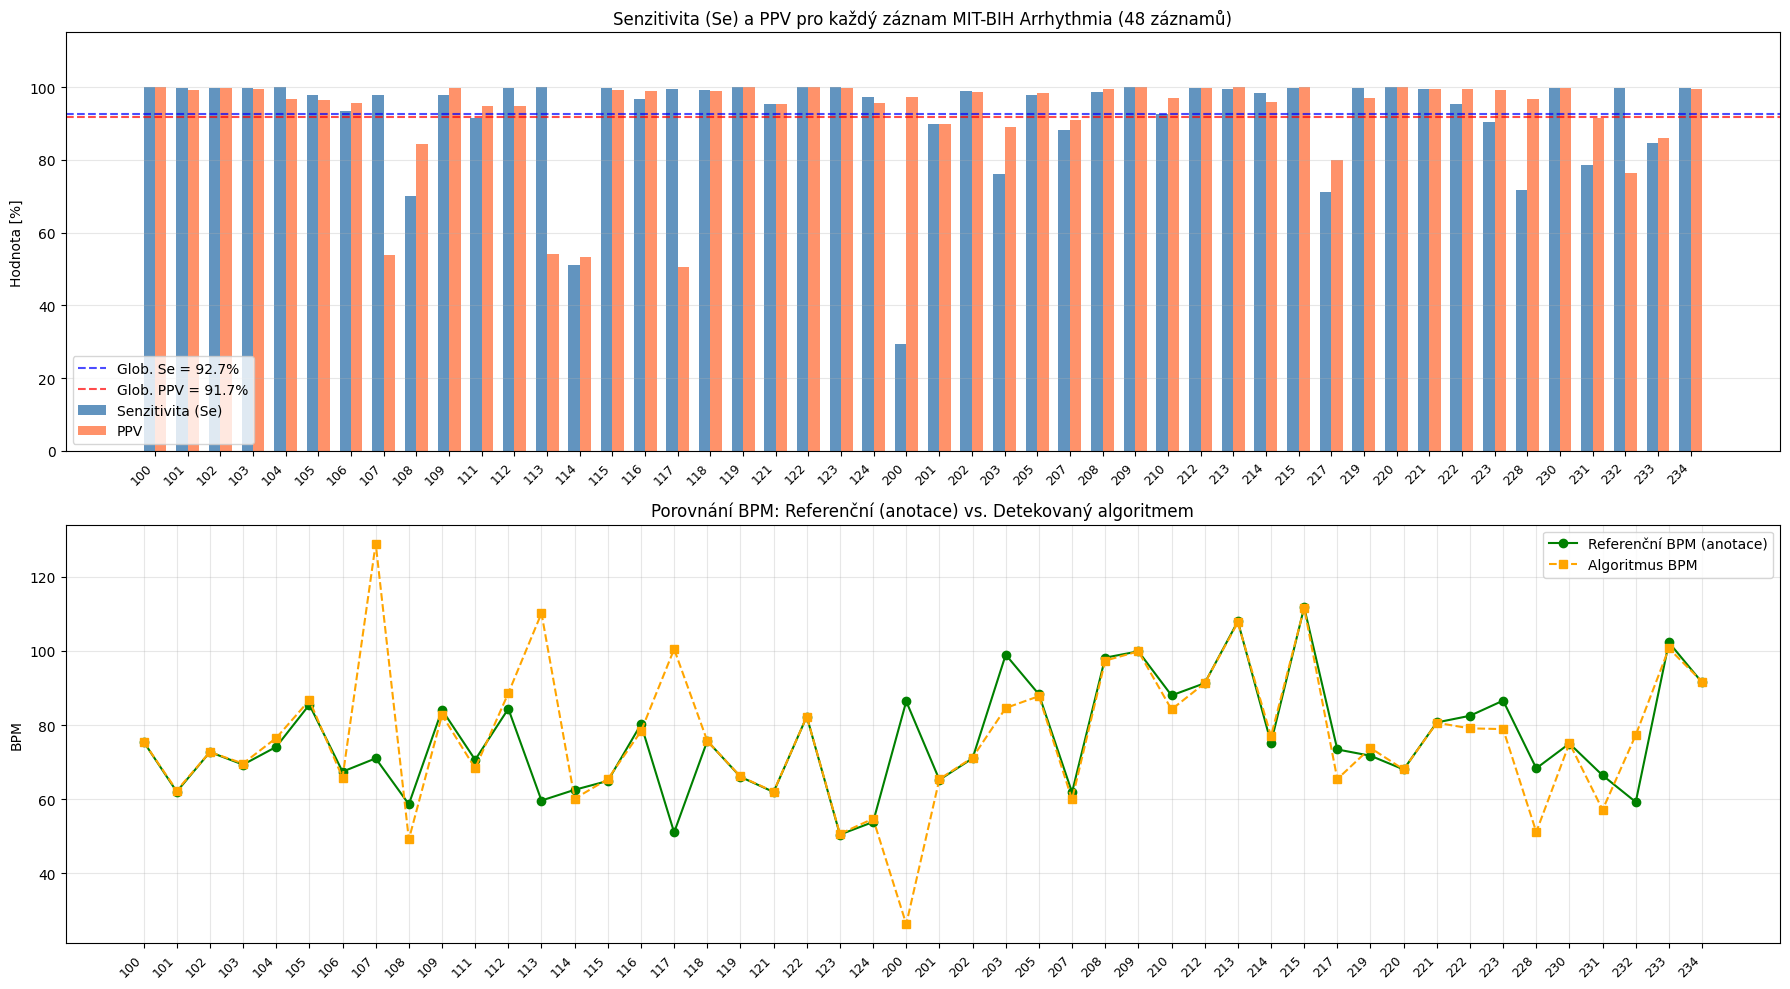

Graf uložen jako mitbih_arrhythmia_vysledky.png


In [15]:
# ============================================================
# Souhrnné statistiky a vizualizace výsledků pro celou databázi
# ============================================================

df_valid = df_mitbih[df_mitbih['Se [%]'] > 0].copy()  # Pouze úspěšně zpracované záznamy

# Globální metriky (přes všechny záznamy dohromady)
glob_TP  = df_valid['TP'].sum()
glob_FP  = df_valid['FP'].sum()
glob_FN  = df_valid['FN'].sum()
glob_Se  = glob_TP / (glob_TP + glob_FN) * 100
glob_PPV = glob_TP / (glob_TP + glob_FP) * 100
glob_F1  = 2 * glob_Se * glob_PPV / (glob_Se + glob_PPV)

print("=" * 55)
print("SOUHRNNÉ VÝSLEDKY - MIT-BIH ARRHYTHMIA DATABÁZE")
print("=" * 55)
print(f"Zpracované záznamy:          {len(df_valid)} / {len(df_mitbih)}")
print(f"Celkem skutečných tepů:      {df_valid['Skutečné tepy'].sum()}")
print(f"Celkem detekovaných tepů:    {df_valid['Detekované tepy'].sum()}")
print(f"Celkem TP / FP / FN:         {glob_TP} / {glob_FP} / {glob_FN}")
print("-" * 55)
print(f"Globální Senzitivita (Se):   {glob_Se:.2f} %")
print(f"Globální PPV:                {glob_PPV:.2f} %")
print(f"Globální F1-skóre:           {glob_F1:.2f} %")
print("=" * 55)

# ---- Graf 1: Se a PPV pro každý záznam ----
zaznamy = df_valid['Záznam'].tolist()
x = np.arange(len(zaznamy))
width = 0.35

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

axes[0].bar(x - width/2, df_valid['Se [%]'], width, label='Senzitivita (Se)', color='steelblue', alpha=0.85)
axes[0].bar(x + width/2, df_valid['PPV [%]'], width, label='PPV', color='coral', alpha=0.85)
axes[0].axhline(y=glob_Se,  color='blue', linestyle='--', alpha=0.7, label=f'Glob. Se = {glob_Se:.1f}%')
axes[0].axhline(y=glob_PPV, color='red',  linestyle='--', alpha=0.7, label=f'Glob. PPV = {glob_PPV:.1f}%')
axes[0].set_xticks(x)
axes[0].set_xticklabels(zaznamy, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Hodnota [%]')
axes[0].set_title('Senzitivita (Se) a PPV pro každý záznam MIT-BIH Arrhythmia (48 záznamů)')
axes[0].legend(loc='lower left')
axes[0].set_ylim([0, 115])
axes[0].grid(True, alpha=0.3, axis='y')

# ---- Graf 2: Referenční vs. detekované BPM ----
axes[1].plot(zaznamy, df_valid['Ref. BPM'], 'o-', color='green', label='Referenční BPM (anotace)', linewidth=1.5)
axes[1].plot(zaznamy, df_valid['Alg. BPM'], 's--', color='orange', label='Algoritmus BPM', linewidth=1.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(zaznamy, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('BPM')
axes[1].set_title('Porovnání BPM: Referenční (anotace) vs. Detekovaný algoritmem')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mitbih_arrhythmia_vysledky.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graf uložen jako mitbih_arrhythmia_vysledky.png")


## 4. Závěr

V této části seminární práce byl vytvořen algoritmus pro detekci tepové frekvence z EKG signálu.
Algoritmus byl aplikován na sadu měření řidičů (DriveDB), kde jsme získali přehled o tepové frekvenci v různých situacích.

Validace byla provedena na **celé databázi MIT-BIH Arrhythmia** (48 záznamů), která obsahuje záznamy s různými typy srdečních arytmií.
Pro každý záznam byly vypočítány metriky: Senzitivita (Se), Pozitivní prediktivní hodnota (PPV) a F1-skóre.
Tolerance pro shodu detekovaného a skutečného R-vrcholu byla nastavena na ±150 ms.

Výsledky ukazují, že algoritmus na čistých signálech (sinusový rytmus) dosahuje vysoké úspěšnosti, ale u záznamů s výraznou arytmií nebo šumem může docházet k falešným detekcím nebo vynechání vrcholů. Pro vyšší robustnost by bylo vhodné implementovat Pan-Tompkinsův algoritmus s pásmovou propustí a derivací signálu.


--------------------------------------------------------------------------

# Zadání 2: Výpočet korelace měřených signálů

## Zadání a Cíl práce
Cílem této části je analyzovat vztahy mezi fyziologickými signály u 13 pacientů z databáze CharisDB.
Konkrétně se zaměřujeme na:
1.  **Vnitřní korelaci:** Výpočet míry shody (Pearsonův koeficient) mezi signály EKG, arteriálním tlakem (ABP) a nitrolebním tlakem (ICP) u každého pacienta.
2.  **Mezipacientskou shodu:** Porovnání tvaru křivky arteriálního tlaku (ABP) mezi všemi pacienty navzájem.

**Data:** Signály z databáze [CharisDB](https://physionet.org/content/charisdb/1.0.0/).
**Zpracování:** Signály jsou normalizovány (centralizace), ošetřeny proti výpadkům (interpolace) a v případě potřeby převzorkovány na jednotnou frekvenci. Pro analýzu ABP jsou signály zarovnány na dominantní vrchol.

## 1. Import knihoven
Importujeme nástroje pro načítání dat (wfdb), zpracování signálu (scipy) a vizualizaci (matplotlib, seaborn).

In [ ]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from scipy import signal as scipy_signal

# Nastavení hezčího vzhledu grafů
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

print("Knihovny načteny.")

## 2. Pomocné funkce
Definujeme funkce pro:
1. **Interpolaci a centralizaci:** Doplnění chybějících dat a odečtení průměru (dle zadání).
2. **Zarovnání na vrchol:** Abychom mohli porovnávat ABP signály pacientů, musíme je srovnat na stejný start.
3. **Převzorkování (Resampling):** Zajišťuje, že všechny signály mají stejnou vzorkovací frekvenci.

In [ ]:
DATA_PATH = 'C:\\Users\\karel\\Documents\\ORM_DB\\psz\\charis' # Cesta k souborům

def zpracovat_signal(signal_data):
    """Interpolace chybějících dat a centralizace kolem nuly."""
    s = pd.Series(signal_data)
    # Doplnění NaN hodnot (lineární interpolace)
    if s.isnull().any():
        s = s.interpolate(method='linear').bfill().ffill()
    clean_vals = s.values
    # Centralizace (odečtení průměru)
    return clean_vals - np.mean(clean_vals)

def zarovnat_na_vrchol(sig, fs):
    """Najde dominantní vrchol na začátku a ořízne signál."""
    limit = int(5 * fs) # Hledáme v prvních 5 sekundách
    start_idx = np.argmax(sig[:limit])
    return sig[start_idx:]

def resample_signal(sig, original_fs, target_fs):
    """Převzorkuje signál na cílovou frekvenci."""
    if original_fs == target_fs:
        return sig
    # Počet vzorků po převzorkování
    num_samples = int(len(sig) * target_fs / original_fs)
    return scipy_signal.resample(sig, num_samples)

## 3. Načtení dat a výpočty
Procházíme soubory `charis1` až `charis13`.
- Načítáme pouze **první hodinu** záznamu.
- Kontrolujeme vzorkovací frekvenci a případně převzorkujeme.
- Počítáme Pearsonův korelační koeficient mezi EKG, ABP a ICP.
- Ukládáme signály ABP pro pozdější hromadné porovnání.

In [ ]:
pocet_pacientu = 13
vysledky_list = []
abp_vsechny = {} # Slovník pro ABP signály
TARGET_FS = None # Nastavíme podle prvního pacienta

print("Zpracovávám pacienty...")

for i in range(1, pocet_pacientu + 1):
    fname = f'charis{i}'
    try:
        # Přečteme hlavičku pro FS
        header = wfdb.rdheader(f'{DATA_PATH}/{fname}')
        fs = header.fs
        
        # Nastavíme cílovou frekvenci podle prvního souboru, pokud ještě není
        if TARGET_FS is None:
            TARGET_FS = fs
            print(f"Referenční frekvence nastavena na: {TARGET_FS} Hz")

        # Načteme 1 hodinu (v původní frekvenci)
        samp_to = int(3600 * fs)
        signals, fields = wfdb.rdsamp(f'{DATA_PATH}/{fname}', sampto=samp_to)
        
        # Najdeme indexy kanálů
        names = fields['sig_name']
        idx_ecg = next((i for i, n in enumerate(names) if 'ECG' in n or 'EKG' in n), None)
        idx_abp = next((i for i, n in enumerate(names) if 'ABP' in n), None)
        idx_icp = next((i for i, n in enumerate(names) if 'ICP' in n), None)
        
        if idx_ecg is not None and idx_abp is not None and idx_icp is not None:
            # Zpracování: Interpolace + Centralizace
            sig_ecg = zpracovat_signal(signals[:, idx_ecg])
            sig_abp = zpracovat_signal(signals[:, idx_abp])
            sig_icp = zpracovat_signal(signals[:, idx_icp])
            
            # Krok navíc: Převzorkování, pokud se fs liší od TARGET_FS
            if fs != TARGET_FS:
                print(f" -> Převzorkování pacienta {i} z {fs}Hz na {TARGET_FS}Hz")
                sig_ecg = resample_signal(sig_ecg, fs, TARGET_FS)
                sig_abp = resample_signal(sig_abp, fs, TARGET_FS)
                sig_icp = resample_signal(sig_icp, fs, TARGET_FS)
            
            # Výpočet korelací (v rámci jednoho pacienta)
            # Matice 3x3 (ECG, ABP, ICP)
            data_matrix = np.vstack([sig_ecg, sig_abp, sig_icp])
            corr_mtx = np.corrcoef(data_matrix)
            
            # Uložení výsledků
            vysledky_list.append({
                'Pacient': fname,
                'ECG-ABP': corr_mtx[0, 1],
                'ECG-ICP': corr_mtx[0, 2],
                'ABP-ICP': corr_mtx[1, 2]
            })
            
            # Uložení zarovnaného ABP pro druhou část úkolu
            abp_aligned = zarovnat_na_vrchol(sig_abp, TARGET_FS)
            abp_vsechny[fname] = abp_aligned
            
        else:
            print(f"Pacient {i}: Chybí některý kanál. Nalezeno: {names}")
            
    except Exception as e:
        print(f"Chyba u {fname}: {e}")

# Vytvoření tabulky
df_vysledky = pd.DataFrame(vysledky_list)
print("Hotovo.")

Zpracovávám pacienty...
Referenční frekvence nastavena na: 50 Hz
Hotovo.


## 4. Tabulka výsledků
Přehled korelací mezi signály u jednotlivých pacientů.

In [ ]:
# Zobrazení tabulky
display(df_vysledky)

# Uložení do CSV pro seminární práci
df_vysledky.to_csv('vysledky_korelace.csv', index=False)

,Pacient,ECG-ABP,ECG-ICP,ABP-ICP
0,charis1,0.030860,0.074911,-0.019408
1,charis2,-0.097864,-0.082018,0.496355
2,charis3,-0.089452,-0.146513,0.848934
3,charis4,0.023797,-0.112938,0.014334
4,charis5,0.023855,0.029666,0.001559
5,charis6,-0.403322,-0.356553,0.520743
6,charis7,-0.086149,-0.083786,0.615998
7,charis8,0.127307,-0.042189,0.326453
8,charis9,0.070829,0.028326,0.281382
9,charis10,0.301412,-0.023157,0.532484


## 5. Grafický výstup: Analýza jednoho pacienta
Zde vizualizujeme míru shody pro vybraného pacienta (např. charis1).
Vlevo: Časový průběh signálů (detail 10 sekund).
Vpravo: Teplotní mapa (Heatmap) korelačních koeficientů, která graficky vyjadřuje míru shody.

Vizualizace pro pacienta: charis1


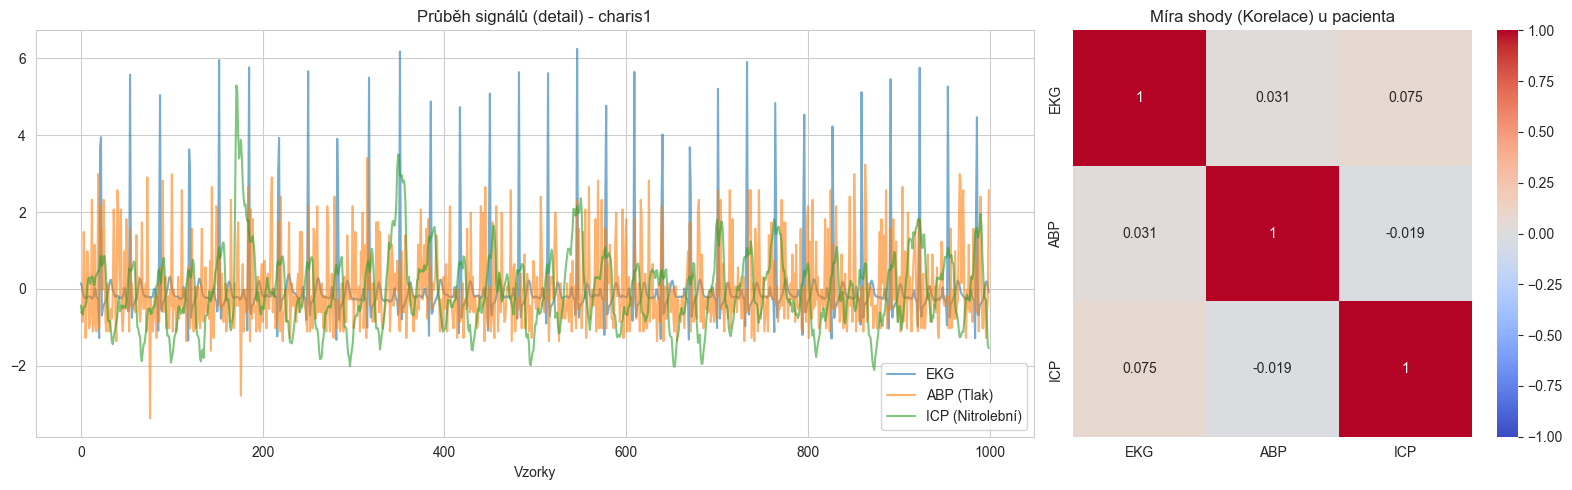

In [ ]:
# Vybereme pacienta, např. prvního v seznamu
ukazka_pacient = vysledky_list[0]['Pacient'] # charis1
print(f"Vizualizace pro pacienta: {ukazka_pacient}")

# Znovu načteme kousek dat pro graf (nebo použijeme z paměti, ale načtení je čistší pro ukázku)
# Pro graf použijeme data, která jsme si uložili v loopu? Ne, to by bylo moc paměti.
# Rychle načteme znovu a upravíme jen pro graf:
sig_graph, f_graph = wfdb.rdsamp(f'{DATA_PATH}/{ukazka_pacient}', sampto=1000)
df_graph = pd.DataFrame(sig_graph, columns=f_graph['sig_name'])

# Najdeme sloupce
c_ecg = [c for c in df_graph.columns if 'ECG' in c or 'EKG' in c][0]
c_abp = [c for c in df_graph.columns if 'ABP' in c][0]
c_icp = [c for c in df_graph.columns if 'ICP' in c][0]

# Normalizace pro hezčí graf (jen pro vizualizaci)
def norm(x): return (x - np.mean(x)) / np.std(x)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2, 1]})

# GRAF 1: Časový průběh
axes[0].plot(norm(df_graph[c_ecg]), label='EKG', alpha=0.6)
axes[0].plot(norm(df_graph[c_abp]), label='ABP (Tlak)', alpha=0.6)
axes[0].plot(norm(df_graph[c_icp]), label='ICP (Nitrolební)', alpha=0.6)
axes[0].set_title(f'Průběh signálů (detail) - {ukazka_pacient}')
axes[0].set_xlabel('Vzorky')
axes[0].legend()

# GRAF 2: Heatmapa korelace pro tohoto pacienta
# Vezmeme data z naší výsledné tabulky pro tohoto pacienta
row = df_vysledky[df_vysledky['Pacient'] == ukazka_pacient].iloc[0]
matrix_data = [
    [1.0, row['ECG-ABP'], row['ECG-ICP']],
    [row['ECG-ABP'], 1.0, row['ABP-ICP']],
    [row['ECG-ICP'], row['ABP-ICP'], 1.0]
]
sns.heatmap(matrix_data, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            xticklabels=['EKG', 'ABP', 'ICP'], yticklabels=['EKG', 'ABP', 'ICP'], ax=axes[1])
axes[1].set_title('Míra shody (Korelace) u pacienta')

plt.tight_layout()
plt.show()

## 6. Grafický výstup: Mapa shody ABP mezi pacienty
Tento graf zobrazuje korelaci tvaru křivky krevního tlaku (ABP) mezi všemi pacienty navzájem.
Signály byly časově srovnány podle dominantního vrcholu.

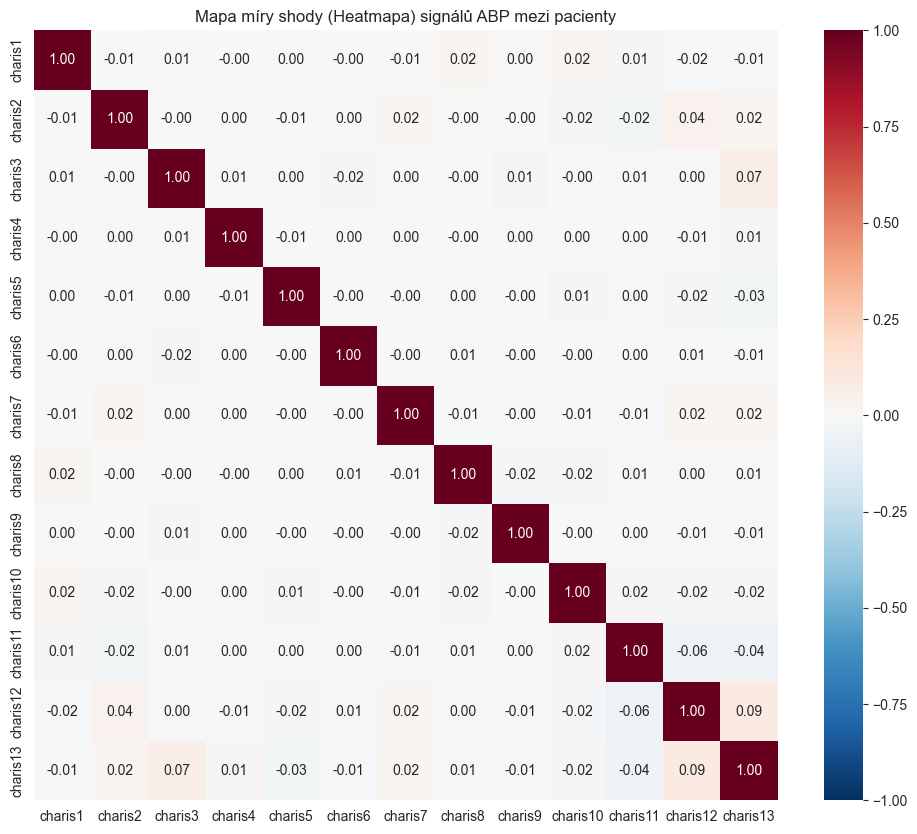

,charis1,charis2,charis3,charis4,charis5,charis6,charis7,charis8,charis9,charis10,charis11,charis12,charis13
charis1,1.000000,-0.005415,0.006721,-0.002387,0.003414,-0.003812,-0.007594,0.017446,0.003846,0.018122,0.013513,-0.015102,-0.013175
charis2,-0.005415,1.000000,-0.000440,0.002383,-0.006498,0.001977,0.015888,-0.004474,-0.004365,-0.017658,-0.024523,0.043613,0.021651
charis3,0.006721,-0.000440,1.000000,0.005182,0.003214,-0.015806,0.002394,-0.004205,0.011856,-0.000143,0.006062,0.001662,0.068928
charis4,-0.002387,0.002383,0.005182,1.000000,-0.007122,0.004012,0.000091,-0.003939,0.001611,0.004166,0.000001,-0.013273,0.011403
charis5,0.003414,-0.006498,0.003214,-0.007122,1.000000,-0.001484,-0.003408,0.003788,-0.000983,0.009411,0.003361,-0.018060,-0.025519
charis6,-0.003812,0.001977,-0.015806,0.004012,-0.001484,1.000000,-0.004884,0.005413,-0.003742,-0.000842,0.002712,0.006741,-0.014401
charis7,-0.007594,0.015888,0.002394,0.000091,-0.003408,-0.004884,1.000000,-0.005621,-0.001772,-0.007199,-0.010817,0.019870,0.018950
charis8,0.017446,-0.004474,-0.004205,-0.003939,0.003788,0.005413,-0.005621,1.000000,-0.019919,-0.015631,0.006756,0.001365,0.007340
charis9,0.003846,-0.004365,0.011856,0.001611,-0.000983,-0.003742,-0.001772,-0.019919,1.000000,-0.003939,0.002237,-0.009979,-0.013754
charis10,0.018122,-0.017658,-0.000143,0.004166,0.009411,-0.000842,-0.007199,-0.015631,-0.003939,1.000000,0.015312,-0.017047,-0.022016


In [ ]:
# 1. Najdeme nejkratší délku (abychom mohli vytvořit matici)
min_len = min(len(s) for s in abp_vsechny.values())

# 2. Vytvoříme DataFrame (sloupce = pacienti)
df_abp_matrix = pd.DataFrame({k: v[:min_len] for k, v in abp_vsechny.items()})

# 3. Výpočet korelační matice
corr_matrix_abp = df_abp_matrix.corr()

# 4. Vykreslení velké Heatmapy
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_abp, annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa míry shody (Heatmapa) signálů ABP mezi pacienty')
plt.show()


display(corr_matrix_abp)
corr_matrix_abp.to_csv("abp_korelace_matice.csv")


## 7. Závěr a slovní zhodnocení

V této části práce jsme provedli korelační analýzu signálů EKG, ABP a ICP u 13 pacientů. Signály byly před výpočtem upraveny (interpolace, centralizace, převzorkování a časové zarovnání). Byla stanovena míra lineární závislosti mezi signály u jednotlivých pacientů i mezi ABP signály napříč pacienty. Výsledky ukazují, že korelační analýza je vhodným nástrojem pro posouzení podobnosti fyziologických signálů.
